# Diagnóstico del pipeline de visión KenKen

Este notebook no entrena el modelo. Muestra cada etapa del procesamiento de una imagen tomada con cámara y señala dónde falla: contorno, perspectiva, grilla, jaulas, glyphs o clasificación.

In [70]:
from pathlib import Path
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'vision' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

IMAGE_PATH = PROJECT_ROOT / 'prueba4.jpg'
MODEL_PATH = PROJECT_ROOT / 'vision' / 'glyph_cnn.pt'
print('Imagen:', IMAGE_PATH)
print('Modelo:', MODEL_PATH)
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f'Coloca prueba.jpg en la raíz del proyecto: {PROJECT_ROOT}')

Imagen: /home/alexc0dex/Escritorio/UPC/Ciclo_8/Topicos/TB1/Kenken/kenken-cv_project/prueba4.jpg
Modelo: /home/alexc0dex/Escritorio/UPC/Ciclo_8/Topicos/TB1/Kenken/kenken-cv_project/vision/glyph_cnn.pt


## 1. Imagen original y normalización de iluminación

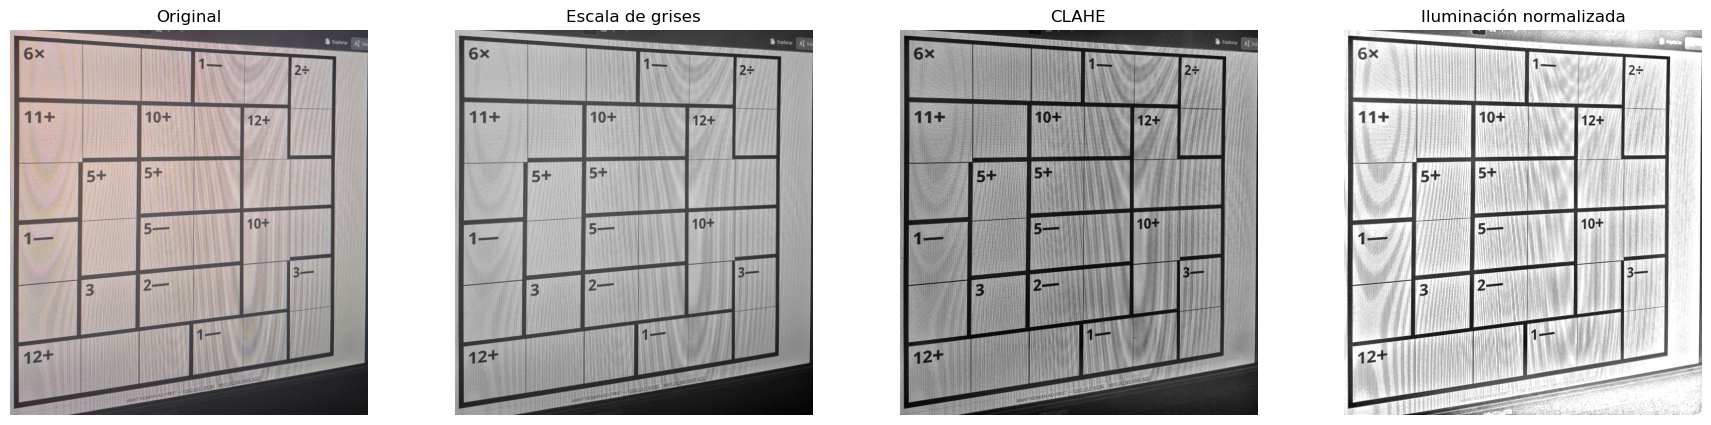

In [71]:
image = cv2.imread(str(IMAGE_PATH))
if image is None:
    raise ValueError(f'OpenCV no pudo leer {IMAGE_PATH}')

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray_clahe = clahe.apply(gray)
background = cv2.GaussianBlur(gray_clahe, (0, 0), 25)
normalized = cv2.divide(gray_clahe, background, scale=255)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for axis, data, title in zip(
    axes,
    [cv2.cvtColor(image, cv2.COLOR_BGR2RGB), gray, gray_clahe, normalized],
    ['Original', 'Escala de grises', 'CLAHE', 'Iluminación normalizada'],
):
    axis.imshow(data, cmap=None if data.ndim == 3 else 'gray')
    axis.set_title(title)
    axis.axis('off')
plt.show()

## 2. Umbral y contornos candidatos

Esta etapa permite ver si la cámara produce un contorno externo útil. Si no aparece un cuadrilátero grande alrededor del tablero, el fallo está antes de la CNN.

Contornos encontrados: 2830
Candidatos grandes: [(0.781, 4)]
OK: existe al menos un contorno cuadrilateral candidato.


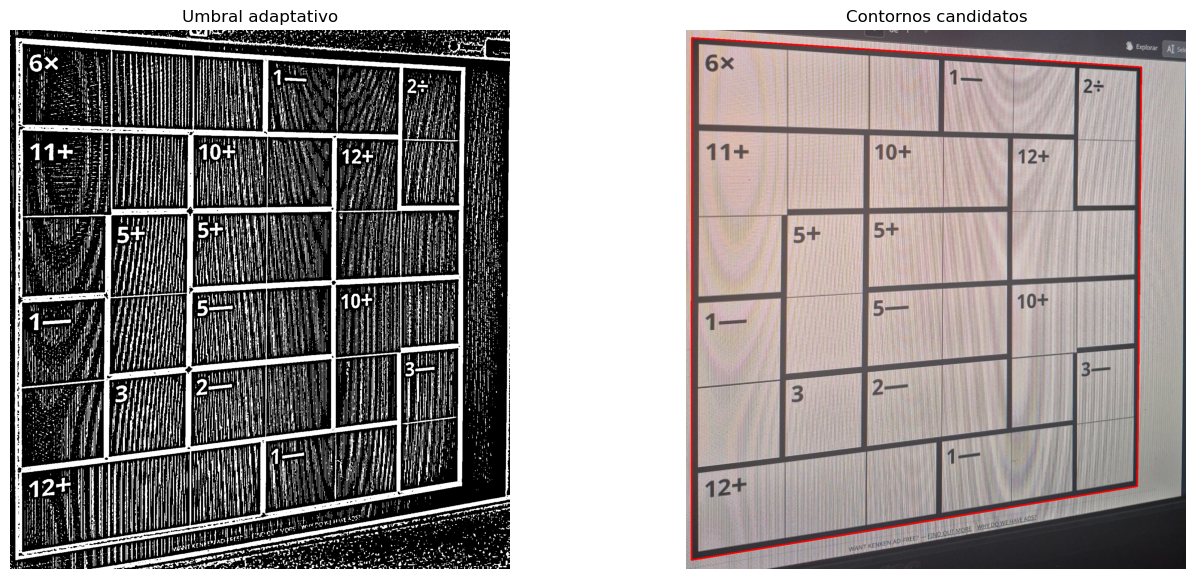

In [72]:
threshold = cv2.adaptiveThreshold(
    cv2.GaussianBlur(normalized, (5, 5), 0), 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 10
)
contours, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
overlay = image.copy()
candidates = []
image_area = image.shape[0] * image.shape[1]
for contour in sorted(contours, key=cv2.contourArea, reverse=True)[:20]:
    area = cv2.contourArea(contour)
    if area < 0.05 * image_area:
        continue
    perimeter = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.02 * perimeter, True)
    candidates.append((area, len(approx), approx))
    cv2.drawContours(overlay, [approx], -1, (0, 0, 255), 3)

print('Contornos encontrados:', len(contours))
print('Candidatos grandes:', [(round(a / image_area, 3), corners) for a, corners, _ in candidates])
if not candidates:
    print('FALLO: no hay un contorno grande candidato para la cuadrícula.')
elif not any(corners == 4 for _, corners, _ in candidates):
    print('ADVERTENCIA: hay contornos grandes, pero ninguno es cuadrilateral.')
else:
    print('OK: existe al menos un contorno cuadrilateral candidato.')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(threshold, cmap='gray')
axes[0].set_title('Umbral adaptativo')
axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title('Contornos candidatos')
for axis in axes:
    axis.axis('off')
plt.show()

## 3. Perspectiva corregida y binarización usada por el pipeline

OK: preprocess terminó.


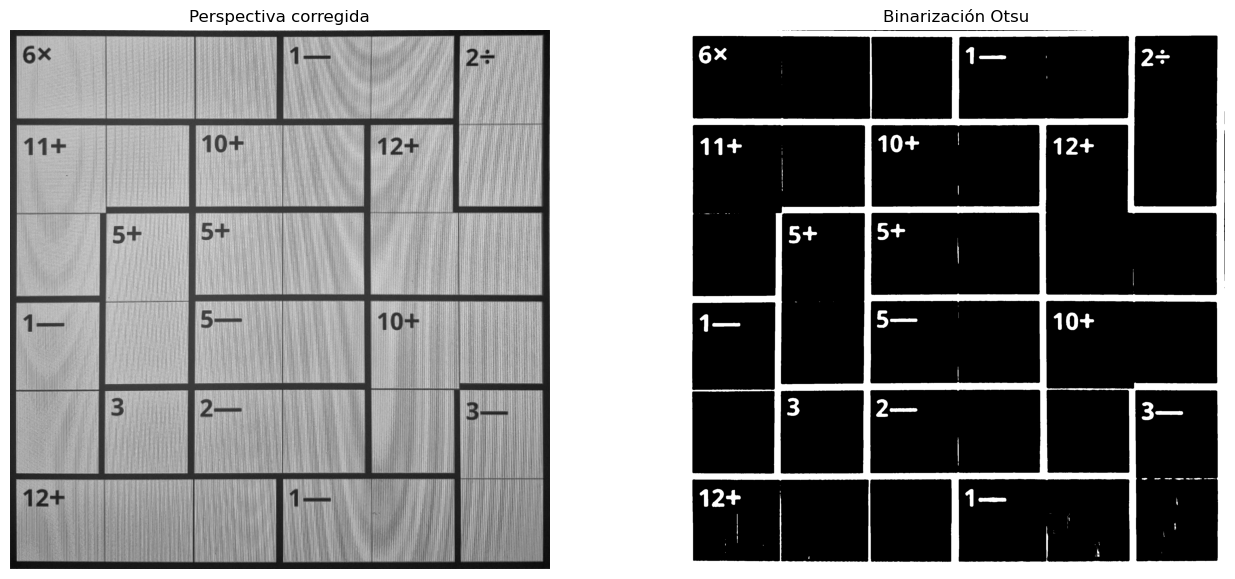

In [73]:
from vision.model import preprocess, find_grid, edge_scores, cage_cells

try:
    warp, ink = preprocess(image)
    print('OK: preprocess terminó.')
except Exception as error:
    print('FALLO EN PREPROCESAMIENTO:', type(error).__name__, error)
    warp, ink = None, None

if warp is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(warp, cmap='gray')
    axes[0].set_title('Perspectiva corregida')
    axes[1].imshow(ink, cmap='gray')
    axes[1].set_title('Binarización Otsu')
    for axis in axes:
        axis.axis('off')
    plt.show()

## 4. Detección de grilla y líneas

OK: grilla detectada como 6x6.


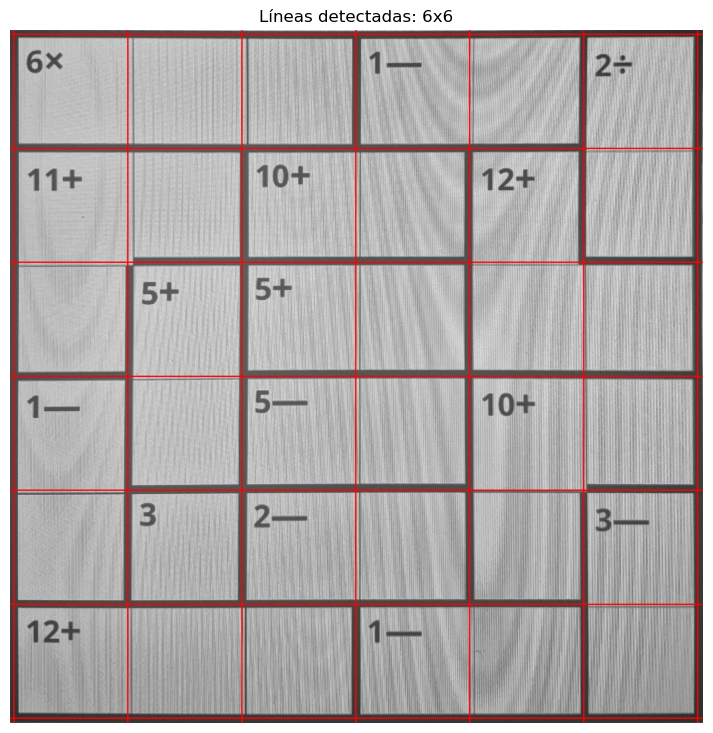

Jaulas detectadas: 16
Tamaños de jaulas: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3]
OK: las jaulas fueron agrupadas.


In [74]:
grid_result = None
if warp is not None:
    try:
        n, xs, ys = find_grid(warp)
        grid_result = (n, xs, ys)
        print(f'OK: grilla detectada como {n}x{n}.')
        if n not in {3, 4, 5, 6, 7, 8, 9}:
            print('ADVERTENCIA: tamaño de grilla inesperado.')
        grid_overlay = cv2.cvtColor(warp, cv2.COLOR_GRAY2RGB)
        for x in xs.astype(int):
            cv2.line(grid_overlay, (x, 0), (x, grid_overlay.shape[0] - 1), (255, 0, 0), 3)
        for y in ys.astype(int):
            cv2.line(grid_overlay, (0, y), (grid_overlay.shape[1] - 1, y), (255, 0, 0), 3)
        plt.figure(figsize=(9, 9))
        plt.imshow(grid_overlay)
        plt.title(f'Líneas detectadas: {n}x{n}')
        plt.axis('off')
        plt.show()
    except Exception as error:
        print('FALLO EN DETECCIÓN DE GRILLA:', type(error).__name__, error)

if grid_result is not None:
    n, xs, ys = grid_result
    vertical, horizontal = edge_scores(ink, n, xs, ys)
    groups = cage_cells(n, vertical, horizontal)
    print('Jaulas detectadas:', len(groups))
    print('Tamaños de jaulas:', sorted(len(group) for group in groups))
    if len(groups) == n * n:
        print('ADVERTENCIA: cada celda quedó como una jaula independiente.')
    else:
        print('OK: las jaulas fueron agrupadas.')

## 5. Segmentación y clasificación de glyphs

Aquí se identifica si el fallo restante está en los recortes o en el modelo CNN.

Jaulas procesadas: 16
Fallos de glyph/decode: 0
OK: todos los glyphs pudieron segmentarse y decodificarse.


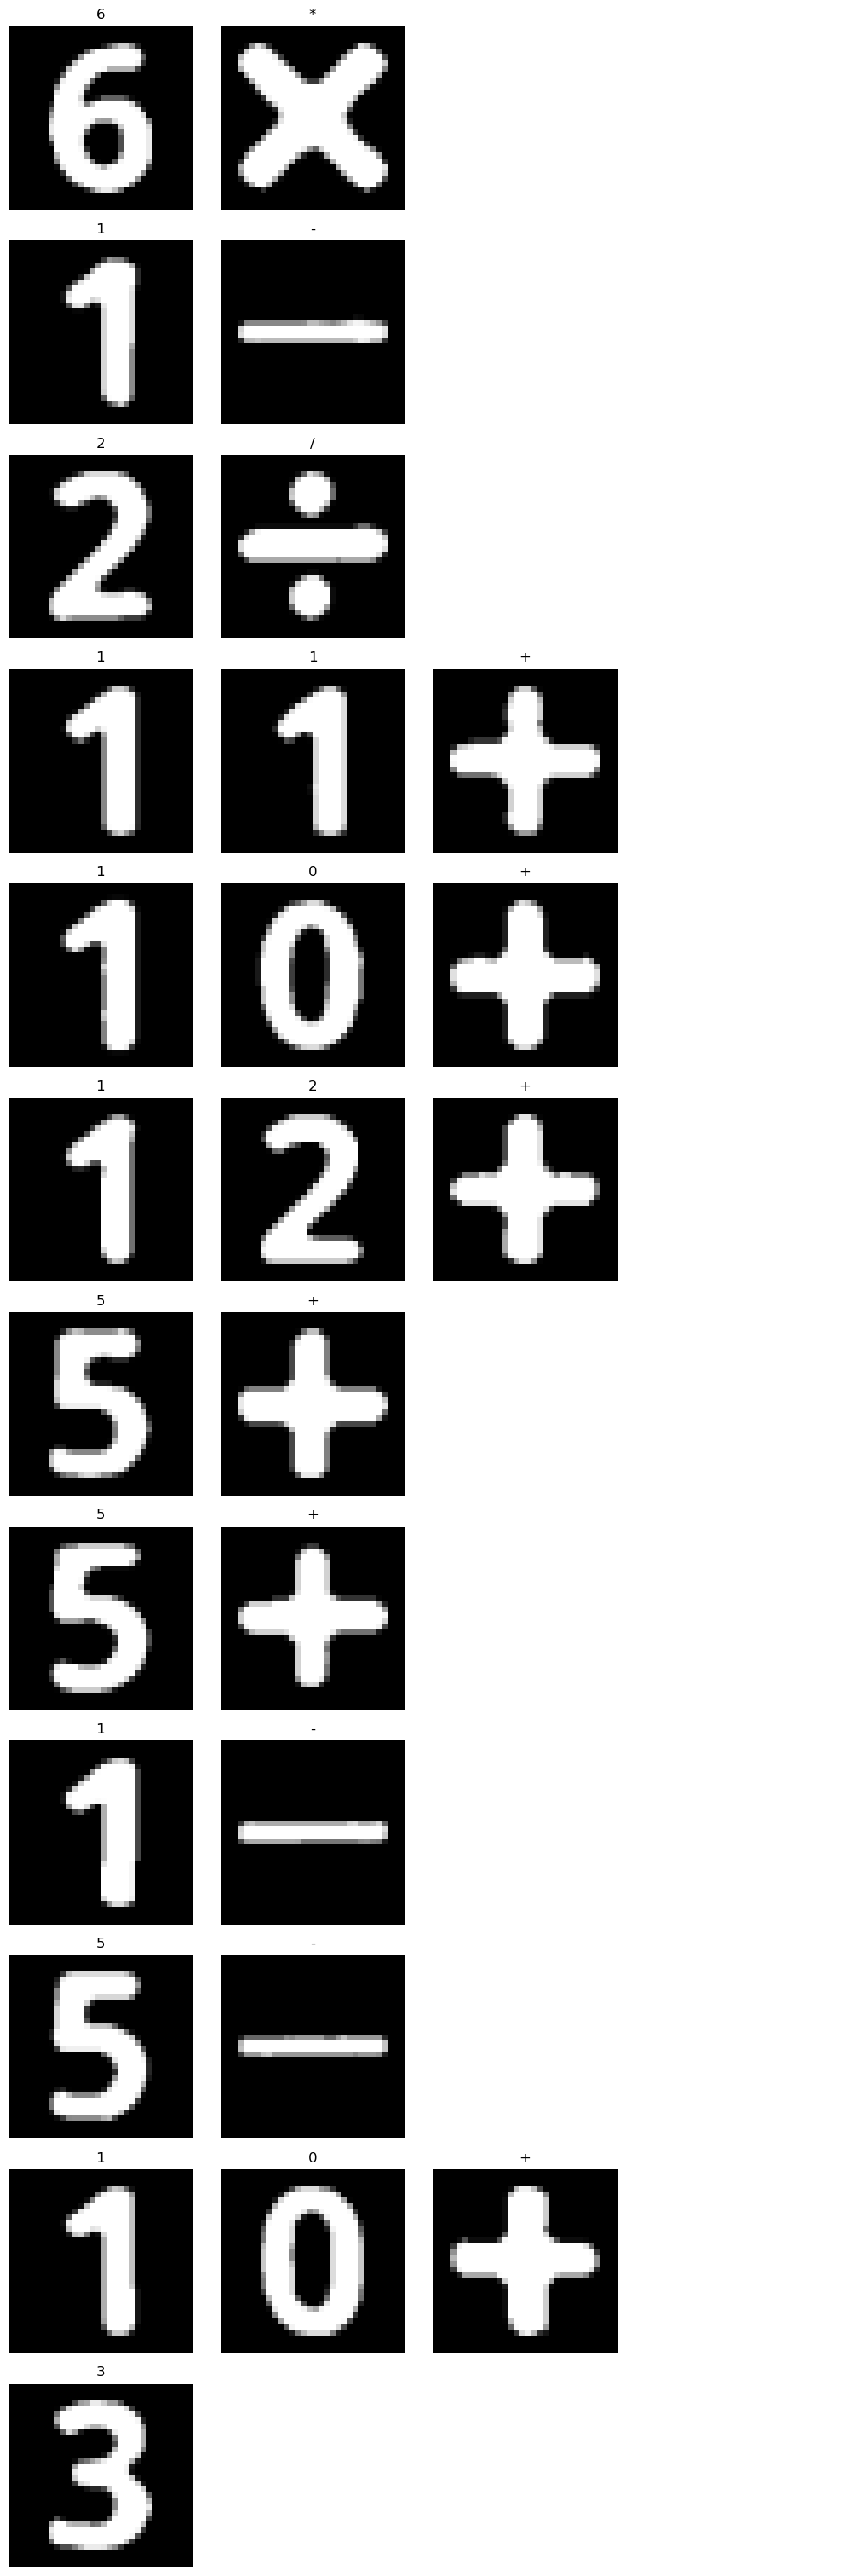

In [75]:
if grid_result is not None:
    from vision.model import load_model, segment_label, classify, decode

    model = load_model(MODEL_PATH)
    failures = []
    previews = []
    for index, cells in enumerate(groups):
        r, c = min(map(tuple, cells))
        try:
            glyphs = segment_label(ink, xs, ys, r, c)
            chars = classify(model, glyphs)
            clue = decode(chars)
            if clue is None:
                failures.append((index, cells, 'decode', chars))
            if index < 12:
                previews.append((index, cells, glyphs, chars, clue))
        except Exception as error:
            failures.append((index, cells, type(error).__name__, str(error)))

    print('Jaulas procesadas:', len(groups))
    print('Fallos de glyph/decode:', len(failures))
    if failures:
        print('Ejemplos:', failures[:5])
    else:
        print('OK: todos los glyphs pudieron segmentarse y decodificarse.')

    if previews:
        fig, axes = plt.subplots(len(previews), 4, figsize=(10, 2.5 * len(previews)))
        axes = np.atleast_2d(axes)
        for row, (index, cells, glyphs, chars, clue) in enumerate(previews):
            for column in range(4):
                axes[row, column].axis('off')
            for column, glyph in enumerate(glyphs[:4]):
                axes[row, column].imshow(glyph, cmap='gray')
                axes[row, column].set_title(chars[column] if column < len(chars) else '?')
            axes[row, 3].set_xlabel(f'jaula {index}: {clue}')
        plt.tight_layout()
        plt.show()


In [76]:
import json
from vision.model import parse_image, export_json

PUZZLE_PATH = PROJECT_ROOT / 'puzzle.json'
clues = [preview[4] for preview in previews]

board = parse_image(IMAGE_PATH, model)
print('Imagen:', board['filename'])
print('Tamaño detectado:', board['n'])
print('Jaulas detectadas:', len(board['cages']))
print(export_json([str(IMAGE_PATH)], model, PUZZLE_PATH))


Imagen: prueba4.jpg
Tamaño detectado: 6
Jaulas detectadas: 16
/home/alexc0dex/Escritorio/UPC/Ciclo_8/Topicos/TB1/Kenken/kenken-cv_project/puzzle.json


In [77]:
from solver import solve_detected_json

solved = solve_detected_json(PUZZLE_PATH)
for row in solved['solution']:
    print(' '.join(map(str, row)))


3 2 1 5 4 6
2 5 4 6 1 3
4 1 3 2 6 5
5 4 6 1 3 2
6 3 2 4 5 1
1 6 5 3 2 4
